# Machine Learning First   
Classical Machine Learning refers to a set of learning algorithms that extract patterns from data without using deep neural networks. These methods typically require manual feature engineering and perform very well on structured (tabular) data. Algorithms such as Linear/Logistic Regression, SVM, KNN, Decision Tree, Random Forest, and Gradient Boosting fall into this category. They are computationally lighter than Deep Learning, require less data, have higher interpretability (especially linear and tree-based models), and are still considered the standard for industrial prediction, classification, and regression problems.


In [1]:
# basic
import os

# Analysis Package
import numpy as np
import pandas as pd

# Plot Package
import matplotlib.pyplot as plt
import seaborn as sns



# ML Classic Algorithms

In [4]:
import platform
import psutil

print("System:", platform.system())
print("Node Name:", platform.node())
print("Release:", platform.release())
print("Version:", platform.version())
print("Machine:", platform.machine())
print("Processor:", platform.processor())

print("\nCPU Cores (Physical):", psutil.cpu_count(logical=False))
print("CPU Cores (Logical):", psutil.cpu_count(logical=True))

ram = psutil.virtual_memory()
print("Total RAM (GB):", round(ram.total / (1024**3), 2))

disk = psutil.disk_usage('/')
print("Disk Total (GB):", round(disk.total / (1024**3), 2))



System: Windows
Node Name: MohseND
Release: 11
Version: 10.0.22631
Machine: AMD64
Processor: AMD64 Family 22 Model 48 Stepping 1, AuthenticAMD

CPU Cores (Physical): 4
CPU Cores (Logical): 4
Total RAM (GB): 14.94
Disk Total (GB): 465.06


## 1. Linear Regression   
**Linear Regression** is the simplest and most fundamental supervised learning algorithm for predicting continuous numerical values. It tries to find a linear relationship between the independent variables (features) and the dependent variable (target).  

The main goal of this model is to find the best-fit line by minimizing a cost function (usually **Mean Squared Error**), which reduces the sum of squared differences between the actual and predicted values.  

Because of its simplicity, very fast computation, and excellent interpretability (by examining the feature coefficients), Linear Regression is still a key tool for initial data analysis and understanding linear relationships in business and scientific problems. However, it is sensitive to **outliers** and does not perform well on complex **non‑linear** relationships.   

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRoHNRScxPJPQDYUQ12rmPSEZ8HC_hrgMdRcw&s"
     width="300" height="200"
     style="display:block; margin:0 auto;">

$\hat{y} = ax + b$


SSR : sum of squares error  -> sum(yhat - y)**2  
    $\sum (\hat{y} - y)^2$
<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSPBI5jVzTODAVb26Z6GTvTcIR0kBOT-VfgTg&s"
     width="600" height="400"
     style="display:block; margin:0 auto;">

<img src="https://www.sophieheloisebennett.com/posts/linear-regression-conditional-mean_files/figure-html/unnamed-chunk-6-1.png"
     width="600" height="400"
     style="display:block; margin:0 auto;">

Gradient descent in linear regression  
 
<img src="https://miro.medium.com/v2/resize:fit:810/1*NjH70PMRLxlvYZMPFmupVA.png"
     width="600" height="400"
     style="display:block; margin:0 auto;">



MSE : mean of squared error -> mean(yhat - y)**2  
    $\frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$


MAE : mean absolute error   -> abs(yhat - y)   
    $|\hat{y} - y|$



## 2. Logistic Regression   
Unlike its name, **Logistic Regression** is a classification algorithm used to predict the probability of a sample belonging to one of two classes (typically 0 or 1). This model uses the **Sigmoid Function** to map the output of a linear function to a range between 0 and 1, where these values represent the probability of an event occurring. Trained using optimization algorithms like **Gradient Descent** to minimize **Log Loss**, Logistic Regression is considered the first and most standard choice for binary classification problems in classical machine learning due to its simplicity, very high speed, and provision of interpretable output probabilities.

<img src="https://www.ejable.com/wp-content/uploads/2023/11/linear-regression-vs-logistic-regression-2.webp"
     width="600" height="300"
     style="display:block; margin:0 auto;">

Use sigmoid function   

$$
\sigma(z) = \frac{1}{1 + e^{-z}}

$$


$$
z = \hat{y} = b_1 x_1 + b_2 x_2 + \dots + b_n x_n

$$



## Data Representation in Scikit-Learn

Machine learning is about creating models from data: for that reason, we'll start by discussing how data can be represented.
The best way to think about data within Scikit-Learn is in terms of *tables*.

A basic table is a two-dimensional grid of data, in which the rows represent individual elements of the dataset, and the columns represent quantities related to each of these elements.
For example, consider the [Iris dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set), famously analyzed by Ronald Fisher in 1936.
We can download this dataset in the form of a Pandas `DataFrame` using the [Seaborn](http://seaborn.pydata.org/) library, and take a look at the first few items:

In [4]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Here each row of the data refers to a single observed flower, and the number of rows is the total number of flowers in the dataset.
In general, we will refer to the rows of the matrix as *samples*, and the number of rows as `n_samples`.

Likewise, each column of the data refers to a particular quantitative piece of information that describes each sample.
In general, we will refer to the columns of the matrix as *features*, and the number of columns as `n_features`.

### The Features Matrix

The table layout makes clear that the information can be thought of as a two-dimensional numerical array or matrix, which we will call the *features matrix*.
By convention, this matrix is often stored in a variable named `X`.
The features matrix is assumed to be two-dimensional, with shape `[n_samples, n_features]`, and is most often contained in a NumPy array or a Pandas `DataFrame`, though some Scikit-Learn models also accept SciPy sparse matrices.

The samples (i.e., rows) always refer to the individual objects described by the dataset.
For example, a sample might represent a flower, a person, a document, an image, a sound file, a video, an astronomical object, or anything else you can describe with a set of quantitative measurements.

The features (i.e., columns) always refer to the distinct observations that describe each sample in a quantitative manner.
Features are often real-valued, but may be Boolean or discrete-valued in some cases.

### The Target Array

In addition to the feature matrix `X`, we also generally work with a *label* or *target* array, which by convention we will usually call `y`.
The target array is usually one-dimensional, with length `n_samples`, and is generally contained in a NumPy array or Pandas `Series`.
The target array may have continuous numerical values, or discrete classes/labels.
While some Scikit-Learn estimators do handle multiple target values in the form of a two-dimensional, `[n_samples, n_targets]` target array, we will primarily be working with the common case of a one-dimensional target array.

A common point of confusion is how the target array differs from the other feature columns. The distinguishing characteristic of the target array is that it is usually the quantity we want to *predict from the features*: in statistical terms, it is the dependent variable.
For example, given the preceding data we may wish to construct a model that can predict the species of flower based on the other measurements; in this case, the `species` column would be considered the target array.

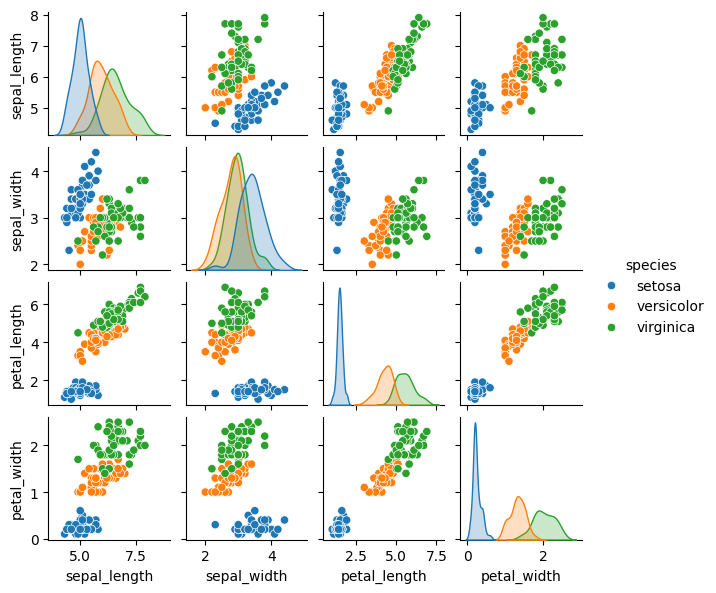

In [6]:
%matplotlib inline
sns.pairplot(iris, hue='species', height=1.5);

For use in Scikit-Learn, we will extract the features matrix and target array from the `DataFrame`, which we can do using some of the Pandas `DataFrame` operations discussed in [Part 3](03.00-Introduction-to-Pandas.ipynb):

In [7]:
X_iris = iris.drop('species', axis=1)
X_iris.shape

(150, 4)

In [8]:
y_iris = iris['species']
y_iris.shape

(150,)